### Project 3. Analysis of fake hotel ratings

In [86]:
import pandas as pd
import numpy as np


In [87]:
df_hotels_0 = pd.read_csv('data/hotels.csv')
display(df_hotels_0.shape)
df_hotels_0.head(3)

(386803, 17)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [88]:
dupl_columns = list(df_hotels_0.columns)
mask = df_hotels_0.duplicated(subset=dupl_columns)
hotels_duplicates = df_hotels_0[mask]
print(f'Число найденных дубликатов: {hotels_duplicates.shape[0]}')

Число найденных дубликатов: 307


In [89]:
df_hotels = df_hotels_0.drop_duplicates(subset=dupl_columns)
print(f'Результирующее число записей: {df_hotels.shape[0]}')

Результирующее число записей: 386496


#### В первую очередь разберем два признака "negative_review" и "positive_review"

In [90]:
# Посмотрим часто встречающиеся отзывы в этом признаке
df_hotels['negative_review'].value_counts().head(30)

negative_review
No Negative            95833
 Nothing               10733
 Nothing                3152
 nothing                1658
 N A                     802
 None                    737
                         606
 N a                     384
 Breakfast               296
 Small room              283
 Location                280
 All good                251
 Everything              250
 Nothing really          239
 none                    223
 nothing                 219
 No complaints           201
 Nil                     197
 Nothing really          195
 Price                   192
 n a                     176
 Nothing to dislike      159
 Nothing at all          154
 Nothing at all          139
 Small rooms             135
 None                    134
 No complaints           129
 All good                115
 NA                      109
 Expensive               105
Name: count, dtype: int64

In [91]:
# Выберем из списка выше важные на мой взгляд фразы
neg_phrases = {
    'no negative', 'nothing', 'n a', 'none', '', 'all good', 
    'everything', 'nothing really', 'no complaints', 'nil', 
    'nothing to dislike', 'nothing at all', 'na'
}


def get_neg_type(text):
    """Задача функции вытащить из отзывов слова-индикаторы, с помощью которых 
    можно дать тот или иной сигнал модели. Список слов-индикаторов был
    подготовлен зараннее - вручную.

    Args:
        text (str): Строка вида 'Nothing to dislike'

    Returns:
        str:  Один из вариантов: 'happy', 'small_room', 'breakfast' или 'other_complaint'
    """
    # Подготовим отзыв для обработки: удалим с краев лишние пробелы и приведем
    # все слова отзыва к нижнемму регистру
    text = text.strip().lower()
    
    # 1. Сначала проверяем на "всем доволен"
    if text in neg_phrases: return 'happy'
    
    # 2. Если не пусто, ищем ключевые слова (самые частые из списка)
    if 'room' in text and ('small' in text or 'tiny' in text):
        return 'small_room'
    
    if 'breakfast' in text: return 'breakfast'
    
    # 3. Если ничего из этого не подошло, но текст есть
    return 'other_complaint'

# Применяем одну функцию
df_hotels['neg_type'] = df_hotels['negative_review'].apply(get_neg_type)

# Создаем бинарные признаки: neg_happy, neg_small_room и т.д.
df_hotels = pd.get_dummies(df_hotels, columns=['neg_type'], prefix='neg', dtype=int)

C:\Users\Николай\AppData\Local\Temp\ipykernel_9820\566796717.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_hotels['neg_type'] = df_hotels['negative_review'].apply(get_neg_type)


##### Переходим к признаку "positive_review"

In [92]:
# Посмотрим часто встречающиеся отзывы в этом признаке
df_hotels['positive_review'].value_counts().head(50)

positive_review
No Positive                    26863
 Location                       6824
 Everything                     1697
 location                       1248
 Nothing                         930
 The location                    828
 Great location                  807
 Good location                   690
 Location                        663
 Breakfast                       455
 Everything                      449
 Friendly staff                  384
 Staff                           347
 Excellent location              296
 Great location                  280
 Location and staff              256
 everything                      233
 Good location                   213
 Nothing                         169
 nothing                         159
 Comfy bed                       158
 The location                    152
 good location                   151
 The staff                       151
 the location                    141
 Location was good               140
 Location was great   

In [93]:
# Создадим список фраз, недовольных клиентов
dis_positive = {
    'no positive', 'nothing', 'none', 'n a', 'nil', 'na', ' ', ''
}

# Создаем признак "dis_positive" - каким отелем клиенты были не довольны
df_hotels['dis_positive'] = df_hotels['positive_review'].str.strip().str.lower().apply(
    lambda x: 1 if x in dis_positive else 0
)

In [94]:
# Создадим список фраз довольных клиентов
pos_phrases = {'everything', 'all', 'every thing', 'everything was perfect'}

# Создаем признак 'is_positive' - каким отелем клиенты остались довольны
df_hotels['is_positive'] = df_hotels['positive_review'].str.strip().str.lower().apply(
    lambda x: 1 if x in pos_phrases else 0
)

In [95]:
def get_pos_type(text):
    """Задача функции вытащить из отзывов слова-индикаторы, с помощью которых 
    можно дать тот или иной сигнал модели. Список слов-индикаторов был
    подготовлен зараннее - вручную.

    Args:
        text (str): Строка вида "Excellent location"

    Returns:
        str: Один из вариантов: 'displeased', 'perfect', 'location' или 'other'
    """
    # Подготовим отзыв к обработке: почистим с краев от лишних пробелов и 
    # приведем все слова отзыва к нижнему регистру
    text = text.strip().lower()
    
    # 1. Проверяем отзыв на "недовольство" отелем
    if text in dis_positive: return 'displeased'
    
    # 2. Проверяем отзыв на полную удовлетворенность отелем3. 
    if text in pos_phrases: return 'perfect'
    
    # 3. Проверяем отзыв на удобное расположение отеля
    if 'location' in text or 'position' in text or 'central' in text: return 'location'
    
    # 4. Проверяем отзыв на прфессионализм персонала
    if 'staff' in text or 'friendly' in text: return 'staff'
    
    return 'other'

# Формируем временный признак 'pos_type' для создания бинарных признаков по каждому 
# слову-индикатору
df_hotels['pos_type'] = df_hotels['positive_review'].apply(get_pos_type)
df_hotels = pd.get_dummies(df_hotels, columns=['pos_type'], prefix='pos', dtype=int)

In [96]:
# Удалим первоисточники
df_hotels = df_hotels.drop(['negative_review', 'positive_review'], axis=1)

In [97]:
# Проверим результат резобработки двух признаков "negative_review" и "positive_review"
list(df_hotels.columns)

['hotel_address',
 'additional_number_of_scoring',
 'review_date',
 'average_score',
 'hotel_name',
 'reviewer_nationality',
 'review_total_negative_word_counts',
 'total_number_of_reviews',
 'review_total_positive_word_counts',
 'total_number_of_reviews_reviewer_has_given',
 'reviewer_score',
 'tags',
 'days_since_review',
 'lat',
 'lng',
 'neg_breakfast',
 'neg_happy',
 'neg_other_complaint',
 'neg_small_room',
 'dis_positive',
 'is_positive',
 'pos_displeased',
 'pos_location',
 'pos_other',
 'pos_perfect',
 'pos_staff']

#### Следующим действием будем обрабатывать признак 'hotel_address'

In [98]:
# Посмотрим сколько уникальных значений имеет данный признак
df_hotels['hotel_address'].nunique()

1493

In [99]:
# Посмотрим как выглядит информация в данном признаке
df_hotels['hotel_address'].value_counts().sample(30)

hotel_address
22 rue d Antin 2nd arr 75002 Paris France                                                          18
Prinsengracht 717 Amsterdam City Center 1017 JW Amsterdam Netherlands                              16
10a Chestnut Plaza Westfield Stratford City Olympic Park Newham London E20 1GL United Kingdom     740
Piazza Giuseppe Missori 1 Milan City Center 20123 Milan Italy                                     456
26 42 Bond Street Ealing London W5 5AA United Kingdom                                              95
23 Rue Vignon 8th arr 75008 Paris France                                                           84
6 rue Chauveau Lagarde 8th arr 75008 Paris France                                                 212
30 Rue de Bassano 16th arr 75016 Paris France                                                      58
29 31 rue de Poitou 3rd arr 75003 Paris France                                                     44
Via Laietana 49 Ciutat Vella 08003 Barcelona Spain                  

#### Выделим из адреса город и страну, я считаю это важными признаками

In [100]:
# Создадим рабочий DF, чтобы данные вводного DF не изменялись.
hotels_df = df_hotels.copy()

# Для удобства создадим временную колонку 'temp'
hotels_df['temp'] = df_hotels['hotel_address'].str.split()

def get_city(address):
    """Признак имеет жесткую структуру расположения данных в ячейке. Поэтому 
    извлечение информации о городе будем осуществлять по индексу, который = -2. 
    Исключение United Kingdom, для данной страны индекс города = -5.
    
    Args:
        address (list): Список вида ['Filmteichstra', 'e', '5', '10', 'Favoriten',
        '1100', 'Vienna', 'Austria'] 

    Returns:
        str: Строка вида 'Vienna' или другой город
    """
    # Проверяем исключение и очищаем от пробелов
    if address[-1].strip() == 'Kingdom':
        return address[-5].strip()
    
    else:
        return address[-2].strip()  # возвращаем название города
    
# Создаем новый признак 'city'
hotels_df['cities'] = hotels_df['temp'].apply(get_city)

def get_country(address):
    """Признак имеет жесткую структуру расположения данных в ячейке. Поэтому 
    извлечение информации о стране будем осуществлять по индексу, который = -1. 
    Исключение United Kingdom, так как название страны состоит из двух слов.

    Args:
        address (list): Список вида ['Filmteichstra', 'e', '5', '10', 'Favoriten',
        '1100', 'Vienna', 'Austria']

    Returns:
        str: Строка вида 'Austria' или название другой 
    """
    # проверяем исключения и очищаем от пробелов
    if address[-1].strip() == 'Kingdom':
        # при исключении возвращаем не элемент по индексу, а 'United Kingdom' 
        return 'United Kingdom' 
     
    else:
        return address[-1].strip()   # возвращаем название страны
    
# Создаем новый признак 'country'    
hotels_df['country'] = hotels_df['temp'].apply(get_country)

# Проверяем наличие новых признаков
hotels_df.sample(5)


,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,...,dis_positive,is_positive,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,temp,cities,country
355353,9 Rue De Li ge 9th arr 75009 Paris France,74,2/4/2016,8.7,Best Western Premier Op ra Li ge,Kenya,0,641,5,5,...,0,0,0,0,0,0,1,"[9, Rue, De, Li, ge, 9th, arr, 75009, Paris, F...",Paris,France
185261,Wrights Lane Kensington and Chelsea London W8 ...,1172,4/26/2016,7.8,Holiday Inn London Kensington,Switzerland,54,5945,7,7,...,0,0,0,0,1,0,0,"[Wrights, Lane, Kensington, and, Chelsea, Lond...",London,United Kingdom
374693,10 West Temple Sheen London SW14 7RT United Ki...,70,6/7/2016,8.3,The Victoria,United Kingdom,41,272,39,11,...,0,0,0,1,0,0,0,"[10, West, Temple, Sheen, London, SW14, 7RT, U...",London,United Kingdom
51019,372 Strand Westminster Borough London WC2R 0JJ...,2288,7/5/2016,8.1,Strand Palace Hotel,United Kingdom,4,9568,7,1,...,0,0,0,0,1,0,0,"[372, Strand, Westminster, Borough, London, WC...",London,United Kingdom
155714,14 15 Langham Place Westminster Borough London...,368,11/5/2015,7.5,Saint Georges Hotel,Germany,97,2092,18,16,...,0,0,0,1,0,0,0,"[14, 15, Langham, Place, Westminster, Borough,...",London,United Kingdom


In [101]:
display(hotels_df['cities'].value_counts())

# проверяем заполненсть колонки
print(f"Количество строк = {hotels_df['cities'].value_counts().sum()}")

print('==================================')

display(hotels_df['country'].value_counts())

# проверяем заполненость колонки
print(f"Количество строк = {hotels_df['country'].value_counts().sum()}")


cities
London       196773
Barcelona     45132
Paris         44528
Amsterdam     43004
Vienna        29177
Milan         27882
Name: count, dtype: int64

Количество строк = 386496


country
United Kingdom    196773
Spain              45132
France             44528
Netherlands        43004
Austria            29177
Italy              27882
Name: count, dtype: int64

Количество строк = 386496


#### Полученные данные очень показательны. Без сравнительного анализа понятно что 'country' и 'city' мультиколлинеарные признаки. Я считаю что признак 'city' важнее, поэтому признак 'country' я удаляю.

In [102]:
# удаляем вспомогательные и лишние признаки
hotels_df = hotels_df.drop(['hotel_address', 'temp', 'country'], axis=1)
hotels_df.shape # проверяем размерность таблицы

(386496, 26)

#### **Задание 4.2**
##### Сколько уникальных названий отелей представлено в наборе данных?

In [103]:
hotels_df['hotel_name'].nunique()

1492

In [104]:
hotels_df['hotel_name']

0                                The May Fair Hotel
1                   Mercure London Bloomsbury Hotel
2                 Legend Saint Germain by Elegancia
3         Mercure Paris 19 Philharmonie La Villette
4                       Golden Tulip Amsterdam West
                            ...                    
386798                              Hotel Moonlight
386799                BEST WESTERN PLUS Amedia Wien
386800                      Bloomsbury Palace Hotel
386801                       The Marble Arch London
386802                        The Nadler Kensington
Name: hotel_name, Length: 386496, dtype: object

#### Из названий отелей будем выделять следующие признаки:
* Сетевые премиум бренды;
* Сетевые бренды среднего класса;
* Не сетевые гостиницы.

In [105]:
# Выделим ключевые слова встечающиеся в названии люксовых отлей.
luxury_keywords = ['luxury', 'royal', 'grand', 'deluxe', 'suite', 'palace', 'spa', 'resort']

# Создадим временную вспомогательную колонку - предобработку строки в список
hotels_df['temp1'] = hotels_df['hotel_name'].str.lower().str.split()

# Создадим бинарный признак разделяющий отели на люкс и не люкс
hotels_df['lux'] = hotels_df['temp1'].apply(
    lambda x: 1 if any(word in x for word in luxury_keywords) else 0)

# Создадим новый признак в котором укажем кол-во слов в названии отеля
hotels_df['amount_word'] = hotels_df['temp1'].apply(len)

# Создадим признак совмещающий два предыдущих признака
hotels_df['lux_weight'] = hotels_df['lux'] * hotels_df['amount_word']

# Посмотрим на результат
print(hotels_df.groupby('lux_weight')['average_score'].mean())
print(hotels_df.groupby('lux_weight')['average_score'].count())


lux_weight
0    8.407314
2    8.440283
3    8.221212
4    8.370145
5    8.171457
6    8.492640
7    8.674985
8    8.330966
9    8.657683
Name: average_score, dtype: float64
lux_weight
0    350936
2      1765
3     10598
4      7426
5     10209
6      2921
7      1711
8       507
9       423
Name: average_score, dtype: int64


In [106]:
hotels_df['review_total_negative_word_counts'].describe()

count    386496.000000
mean         18.539400
std          29.703569
min           0.000000
25%           2.000000
50%           9.000000
75%          23.000000
max         408.000000
Name: review_total_negative_word_counts, dtype: float64

In [107]:
hotels_df['review_total_positive_word_counts'].describe()

count    386496.000000
mean         17.778163
std          21.724766
min           0.000000
25%           5.000000
50%          11.000000
75%          22.000000
max         395.000000
Name: review_total_positive_word_counts, dtype: float64

In [108]:
# Считаем сумму всех слов в отзыве
hotels_df['total_words_in_review'] = hotels_df['review_total_negative_word_counts'] + hotels_df['review_total_positive_word_counts']

# Считаем разность отрицательных положительных слов
hotels_df['diff_words'] = hotels_df['review_total_negative_word_counts'] + hotels_df['review_total_positive_word_counts']

In [109]:
# Удалим вспомогательную и исходную колонки 
hotels_df = hotels_df.drop(['temp1', 'hotel_name', 'lux'], axis=1)

In [110]:
# Посмотрим на результа
hotels_df.sample(10)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,...,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight,total_words_in_review,diff_words
93360,48,7/23/2017,8.8,Australia,0,224,23,15,10.0,"[' Leisure trip ', ' Couple ', ' Superior Doub...",...,0,0,0,0,1,Paris,3,0,23,23
330633,930,9/26/2016,8.9,United Kingdom,9,2836,24,6,9.2,"[' Leisure trip ', ' Couple ', ' Deluxe King o...",...,0,1,0,0,0,London,6,0,33,33
114741,102,7/18/2017,9.6,United States of America,0,604,120,2,10.0,"[' Leisure trip ', ' Family with young childre...",...,0,1,0,0,0,Barcelona,3,0,120,120
57404,142,1/3/2016,8.4,Turkey,0,1781,9,1,9.2,"[' Leisure trip ', ' Couple ', ' Superior Doub...",...,0,1,0,0,0,Vienna,3,0,9,9
91335,254,10/22/2016,9.3,United States of America,0,2011,8,1,10.0,"[' Leisure trip ', ' Couple ', ' Standard Doub...",...,0,0,1,0,0,Milan,3,0,8,8
85850,482,8/1/2016,9.0,Brazil,0,3158,18,5,10.0,"[' Leisure trip ', ' Family with older childre...",...,0,0,1,0,0,Amsterdam,3,0,18,18
336260,170,4/15/2017,8.3,Israel,5,1207,5,2,6.7,"[' Leisure trip ', ' Couple ', ' Standard Doub...",...,0,1,0,0,0,Amsterdam,4,0,10,10
17560,1831,12/10/2015,8.1,United Kingdom,0,7105,6,1,9.2,"[' Leisure trip ', ' Group ', ' Superior Doubl...",...,0,0,0,0,1,London,5,0,6,6
302214,713,4/30/2016,8.3,United Kingdom,10,2826,13,10,9.2,"[' Leisure trip ', ' Couple ', ' Standard Doub...",...,0,1,0,0,0,London,4,0,23,23
72529,804,6/23/2016,9.1,Canada,0,3802,8,2,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",...,0,1,0,0,0,London,3,0,8,8


In [111]:
# # начнем с поиска известных брендов которые встречаются в названии
# df_hotels['hotel_brand'] = df_hotels['hotel_name'].str.split().str[0].str.lower()
# first_world_count = df_hotels['hotel_brand'].value_counts()

# # посмотрим как выглядят первые слова в названии отелей
# first_world_count[300:350]

In [112]:
# # определяем мусорные для нас слова
# potential_chains = first_world_count[(first_world_count > 500)].index.tolist()
# garbage = ['the', 'hotel', 'a', 'an', 'at', 'of', 'and', 'h', 'k', 'm', 'w', 'le', 'st', 'best', 'room', 'my', 'new', 'two', 'ac']

# hotels_chains = [brand for brand in potential_chains if brand not in garbage]
# hotels_chains

#### Закидываем этот список в интеренет. Выделяем сетевые премиум бренды, сетевые бренды среднего класса и не сетевые гостиницы

In [113]:
# # список премиум брендов
# premium_brands = [
#     'hilton', 'marriott', 'hyatt', 'sofitel', 'pullman', 'shangri', 
#     'andaz', 'mondrian', 'westin', 'meridien', 'ritz', 'seasons', 
#     'indigo', 'baglioni', 'palazzo', 'luxury', 'mandarin', 'mgallery',
#     'duomo', 'wellesley'
# ]
# # список брендов среднего класса
# mean_brands = [
#     'holiday', 'nh', 'mercure', 'novotel', 'catalonia', 'doubletree', 
#     'citizenm', 'crowne', 'h10', 'eurostars', 'apex', 'starhotels', 
#     'ramada', 'clayton', 'vincci', 'leonardo', 'pestana', 'thistle', 
#     'western', 'atahotel', 'hesperia', 'timhotel', 'hcc', 'happyculture', 
#     'minihotel', 'una'
# ]

# def ordinal_sign(name):
#     name = name.lower()
#     if any(brand in name for brand in premium_brands):
#         return 2
#     if any(brand in name for brand in mean_brands):
#         return 1
#     return 0

# # создаем новый порядковый признак "hotels_rank" в котором: 
# # сетевые отели премиум класса обозначим - 2, сетевые отели среднего класса  
# # обозначим - 1, не сетевые отели обозначим - 0
# hotels_df['hotels_rank'] = hotels_df['hotel_name'].apply(ordinal_sign)
# hotels_df.head(3)

In [114]:
# display(hotels_df['hotels_rank'].value_counts())       

# # проверяем заполненость колонки
# print(f"Количество строк = {hotels_df['hotels_rank'].value_counts().sum()}")

In [115]:
# # смотрим средний балл по образованным признакам
# print(hotels_df.groupby('hotels_rank')['average_score'].mean())

In [116]:
# # удаляем исходный признак 
# hotels_df = hotels_df.drop('hotel_name', axis=1)

In [117]:
hotels_df.head(3)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,...,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight,total_words_in_review,diff_words
0,581,2/19/2016,8.4,United Kingdom,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",...,0,0,0,0,1,London,4,0,7,7
1,299,1/12/2017,8.3,United Kingdom,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",...,0,1,0,0,0,London,4,0,5,5
2,32,10/18/2016,8.9,China,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",...,1,0,0,0,0,Paris,5,0,6,6


#### Следующий признак с которым я буду работать - 'reviewer_nationality'.

In [118]:
# выделим 15 названий стран из которых чаще чем из остальных стран заселяются 
# клиенты, все остальные названия стран объединим под одним названием - Other 
hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].str.strip()
top_15_country = hotels_df['reviewer_nationality'].value_counts().head(15).index
hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].apply(lambda x: x if x in top_15_country else 'Other')
hotels_df.head(3)

,additional_number_of_scoring,review_date,average_score,reviewer_nationality,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,...,pos_displeased,pos_location,pos_other,pos_perfect,pos_staff,cities,amount_word,lux_weight,total_words_in_review,diff_words
0,581,2/19/2016,8.4,United Kingdom,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",...,0,0,0,0,1,London,4,0,7,7
1,299,1/12/2017,8.3,United Kingdom,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",...,0,1,0,0,0,London,4,0,5,5
2,32,10/18/2016,8.9,Other,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",...,1,0,0,0,0,Paris,5,0,6,6


In [119]:
hotels_df['reviewer_nationality'].value_counts()

# проверяем заполненость колонки
print(f"Количество строк = {hotels_df['reviewer_nationality'].value_counts().sum()}")

Количество строк = 386496


##### Используем способ для кодирования стран — One-Hot Encoding (создание отдельных колонок 0/1 для каждой страны)

In [120]:
hotels_df = pd.get_dummies(hotels_df, columns=['reviewer_nationality'], prefix='nat', dtype=int)

In [121]:
hotels_df.head(3)   # Проверяем наличие новых колонок после кодирования One-Hot Encoding

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,...,nat_Israel,nat_Italy,nat_Netherlands,nat_Other,nat_Saudi Arabia,nat_Switzerland,nat_Turkey,nat_United Arab Emirates,nat_United Kingdom,nat_United States of America
0,581,2/19/2016,8.4,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,...,0,0,0,0,0,0,0,0,1,0
1,299,1/12/2017,8.3,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,...,0,0,0,0,0,0,0,0,1,0
2,32,10/18/2016,8.9,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,...,0,0,0,1,0,0,0,0,0,0


#### Сейчас я буду разбирать, вероятно самый сложный признак - 'tags'  

In [122]:
# посмотрим что из себя представляет информация в данном признаке
hotels_df['tags']. value_counts()[100:120]

tags
[' Leisure trip ', ' Group ', ' Standard Double or Twin Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']     419
[' Leisure trip ', ' Couple ', ' Small Queen Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                 418
[' Leisure trip ', ' Couple ', ' Standard Twin Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']               417
[' Leisure trip ', ' Solo traveler ', ' Single Room ', ' Stayed 2 nights ', ' Submitted from a mobile device ']              408
[' Leisure trip ', ' Couple ', ' King Guest Room ', ' Stayed 1 night ', ' Submitted from a mobile device ']                  407
[' Business trip ', ' Solo traveler ', ' Standard Double Room ', ' Stayed 2 nights ']                                        407
[' Leisure trip ', ' Couple ', ' Superior Double or Twin Room ', ' Stayed 4 nights ', ' Submitted from a mobile device ']    406
[' Leisure trip ', ' Group ', ' Double or Twin Room ', ' Stayed 3 nights ', ' Submitted from

In [123]:
# посмотрю какой тип данных заложен в ячейки данной колонки
type(hotels_df['tags'].iloc[100])

str

#### Из признака 'tags' нужно сделать сделать 5 признаков, я считаю что эти новые признаки будут очень полезны.
* признак №1 **'trip_purpose'** назначение или цель поездки
* признак №2 **'check_in_type'** тип заселения один, двое и т.д.
* признак №3 **'room_type'** тип гостиничного номера
* признак №4 **'duration_of_stay'** длительность пребывания
* признак №5 **'is_mobile'** каким образом был отправлен тэг: с мобильного телефона или ПК

In [124]:
# создаем вспомогательную колонку 'tags_changes'
# в новой колонке произведем преобразование данных, получаем очищенный список тэгов.
hotels_df['tags_changes']= hotels_df['tags'].str.strip("[]' ").str.split(" ', ' ")

#### Задание 4.4
##### Сколько уникальных тегов представлено в наборе данных?

In [125]:
# все тэги разложим по отдельным ячейкам
all_tags_column = hotels_df['tags_changes'].explode()

# Убираем лишние пробелы, для подстраховки
all_tags_column = all_tags_column.str.strip()

# Теперь считаем уникальные
unique_count = all_tags_column.nunique()

print(f"Число уникальных тегов = {unique_count}")

Число уникальных тегов = 2368


#### Задание 4.5
##### Какой тег представлен в наибольшем числе отзывов?

In [126]:
print(f"Самый часто используемый тэг: {all_tags_column.mode()[0]}")

Самый часто используемый тэг: Leisure trip


In [127]:
# проверим равномерность заполнения тегами данных в признаке
count_0 = 0
count_1 = 0
count_2 = 0
for el in hotels_df['tags_changes']:
    if len(el) == 3:
        count_0 += 1
    if len(el) == 2:
        count_1 += 1
    if len(el) == 1:
        count_2 += 1
print(f'количество строк в которых заполнено 3 из 5 тегов = {count_0}')
print(f'количество строк в которых заполнено 2 из 5 тегов = {count_1}')
print(f'количество строк в которых заполнено 1 из 5 тегов = {count_2}')

количество строк в которых заполнено 3 из 5 тегов = 4122
количество строк в которых заполнено 2 из 5 тегов = 65
количество строк в которых заполнено 1 из 5 тегов = 5


In [128]:
# Приступаем к созданию новых признаков с помощью соответствующих функций:

def trip_p(tags_list):
    """По ключевым словам выбираем тег из списка тегов, касающийся цели поездки.
    Заносим найденное ключевое слово  в соответствующую ячейку колонки. Если
    ключевое слово не найдено, в соответсвующую ячеку заносим 'Unknown'. 

    Args:
        tags_list (list): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        str: Одно из значений ['Leisure', 'Business', 'Unknown']
    """
    # ищем нужный тег
    for tag in tags_list:       
        tag = tag.strip().lower() # подготовка к поиску
        
        # ищем цель поездки
        if 'leisure' in tag:
            return 'Leisure'
        
        if 'business' in tag:
            return 'Business'
        
    return 'Unknown'
    
def check_in_t(tags_list): 
    """По ключевым словам выбираем тег из списка тегов, касающийся типа заселения.
    Заносим найденное ключевое слово  в соответствующую ячейку колонки. Если
    ключевое слово не найдено, в соответсвующую ячеку заносим 'Unknown'

    Args:
        tags_list (str): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        str: Одно из значений ['couple', 'solo', 'group', 'family with', 'Unknown']
    """
    # ищем нужный тег
    for tag in tags_list:
        tag = tag.strip().lower() # подготовка к поиску
        
        # Ищем тип группы
        if any(x in tag for x in ['couple', 'solo', 'group', 'family with']):
            return tag
        
    return 'Unknown'
    
def duration(tags_list):
    """По ключевому слову 'stayed' выбираем тег из списка тегов в котором зашита
    информация о количестве ночей. Извлекаем нужные числа из тега и заносим в 
    соответствующую ячейку колонки. Если число не найдено, в соответсвующую ячеку заносим 0

    Args:
        tags_list (list): Список с тегами  вида: ['Business trip', 'Solo traveler',
        'Standard Double Room', 'Stayed 2 nights']

    Returns:
        int: Целое цисло, включая 0 
    """
    # ищем нужный тег
    for tag in tags_list:
        tag = tag.strip().lower() # подготовка к поиску
        
        # извлекаем кол-во ночей проведенных в отеле
        if 'stayed' in tag:
            num = int(''.join(filter(str.isdigit, tag)))
            return num
    return 0   

# Создаем новые признаки с помощью вышеописанных функций
hotels_df['trip_purpose'] = hotels_df['tags_changes'].apply(trip_p)

hotels_df['check_in_type'] = hotels_df['tags_changes'].apply(check_in_t)

hotels_df['duration_of_stay'] = hotels_df['tags_changes'].apply(duration)

# Признак 'is_mobile' сделаем бинарным. Создаем его с помощью lambda функции
hotels_df['is_mobile'] = hotels_df['tags_changes'].apply(
    lambda x: 1 if 'Submitted from a mobile device' in x else 0)

# Проверяем наличие в таблице новых признаков
hotels_df.head()
    

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,...,nat_Switzerland,nat_Turkey,nat_United Arab Emirates,nat_United Kingdom,nat_United States of America,tags_changes,trip_purpose,check_in_type,duration_of_stay,is_mobile
0,581,2/19/2016,8.4,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,...,0,0,0,1,0,"[Leisure trip, Couple, Studio Suite, Stayed 2 ...",Leisure,couple,2,1
1,299,1/12/2017,8.3,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,...,0,0,0,1,0,"[Business trip, Couple, Standard Double Room, ...",Business,couple,1,0
2,32,10/18/2016,8.9,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,...,0,0,0,0,0,"[Leisure trip, Solo traveler, Modern Double Ro...",Leisure,solo traveler,3,1
3,34,9/22/2015,7.5,0,607,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,...,0,0,0,1,0,"[Leisure trip, Solo traveler, Standard Room wi...",Leisure,solo traveler,1,0
4,914,3/5/2016,8.5,4,7586,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,...,0,0,0,0,0,"[Business trip, Couple, Standard Double or Twi...",Business,couple,6,0


In [179]:
hotels_df['duration_of_stay'].value_counts()

duration_of_stay
1     145296
2     100176
3      71940
4      35708
5      15592
6       7388
7       5541
8       1907
9        966
10       662
11       305
12       217
14       184
13       174
0        146
15        87
16        38
17        27
18        24
19        23
21        19
20        17
27        10
30        10
22         8
28         7
26         6
23         6
24         5
25         4
29         3
Name: count, dtype: int64

In [129]:
display(hotels_df['trip_purpose'].value_counts())
hotels_df['trip_purpose'].value_counts().sum()

trip_purpose
Leisure     313353
Business     61952
Unknown      11191
Name: count, dtype: int64

np.int64(386496)

#### Преобоазуем признак 'trip_purpose' в порядковый вот по такому принципу: 
* Unknown — 0;
* Leisure — 1;
* Business — 2.

**Пояснения**. Почему 'Business' "лучше" чем 'Leisure'. Бизнес-путешественник — это профессиональный гость: у него большой опыт посещения разных отелей, он может сравнивать и более правильно оценивать. Это «критичный» клиент - ему важны мелочи: работающий Wi-Fi, розетка у стола, быстрый чек-ин. Любой отклонение от "нормы" вызывает снижение оценки.

In [130]:
hotels_df['trip_purpose'] = hotels_df['trip_purpose'].replace(
    {'Leisure': 1, 'Business': 2, 'Unknown': 0})

C:\Users\Николай\AppData\Local\Temp\ipykernel_9820\3905455270.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hotels_df['trip_purpose'] = hotels_df['trip_purpose'].replace(


In [131]:
display(hotels_df['check_in_type'].value_counts())
hotels_df['check_in_type'].value_counts().sum()

check_in_type
couple                        189046
solo traveler                  81166
group                          49057
family with young children     45810
family with older children     19787
Unknown                         1630
Name: count, dtype: int64

np.int64(386496)

##### Для кодирования признака 'check_in_type' используем способ — One-Hot Encoding (создание отдельных колонок 0/1 для каждой страны)

In [132]:
hotels_df = pd.get_dummies(hotels_df, columns=['check_in_type'], prefix='get', dtype=int)

In [133]:
hotels_df.head(3)   # Проверяем наличие новых колонок после кодирования One-Hot Encoding

,additional_number_of_scoring,review_date,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,...,tags_changes,trip_purpose,duration_of_stay,is_mobile,get_Unknown,get_couple,get_family with older children,get_family with young children,get_group,get_solo traveler
0,581,2/19/2016,8.4,3,1994,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,...,"[Leisure trip, Couple, Studio Suite, Stayed 2 ...",1,2,1,0,1,0,0,0,0
1,299,1/12/2017,8.3,3,1361,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,...,"[Business trip, Couple, Standard Double Room, ...",2,1,0,0,1,0,0,0,0
2,32,10/18/2016,8.9,6,406,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,...,"[Leisure trip, Solo traveler, Modern Double Ro...",1,3,1,0,0,0,0,0,1


#### Задание 4.6
##### Из тегов выясните, на сколько ночей чаще всего останавливаются путешественники в отелях?

In [134]:
count_night = hotels_df['duration_of_stay'].mode()[0]
print(f"Чаще всего туристы останавливаются в отеле на: {count_night} ночь(ей)")

# Проверяем заполненность признака
hotels_df['duration_of_stay'].value_counts().sum()

Чаще всего туристы останавливаются в отеле на: 1 ночь(ей)


np.int64(386496)

In [135]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 54 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386496 non-null  int64  
 1   review_date                                 386496 non-null  object 
 2   average_score                               386496 non-null  float64
 3   review_total_negative_word_counts           386496 non-null  int64  
 4   total_number_of_reviews                     386496 non-null  int64  
 5   review_total_positive_word_counts           386496 non-null  int64  
 6   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 7   reviewer_score                              386496 non-null  float64
 8   tags                                        386496 non-null  object 
 9   days_since_review                           386496 non-null  object 
 10  l

In [136]:
hotels_df = hotels_df.drop(['tags', 'tags_changes'], axis=1)
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 52 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386496 non-null  int64  
 1   review_date                                 386496 non-null  object 
 2   average_score                               386496 non-null  float64
 3   review_total_negative_word_counts           386496 non-null  int64  
 4   total_number_of_reviews                     386496 non-null  int64  
 5   review_total_positive_word_counts           386496 non-null  int64  
 6   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 7   reviewer_score                              386496 non-null  float64
 8   days_since_review                           386496 non-null  object 
 9   lat                                         384048 non-null  float64
 10  l

#### Разбираем признаки 'days_since_review' и 'review_date'

In [137]:
# Сначала посмотрим как выглядят данные признака 'days_since_review'
display(hotels_df['days_since_review'].iloc[1])
hotels_df['days_since_review'].value_counts().head(10).sort_index()


'203 day'

days_since_review
1 days     1910
120 day    1702
322 day    1734
338 day    1458
366 day    1352
387 day    1387
394 day    1435
429 day    1413
464 day    1345
534 day    1450
Name: count, dtype: int64

In [138]:
# Извлечем числовые значения из данных признака 'days_since_review'
hotels_df['days_since_review'] = hotels_df['days_since_review'].str.split().str[0].astype(int)

# Преобразуем даты в признаке 'review_date', представленные в виде строк в тип datetime
hotels_df['review_date'] = pd.to_datetime(hotels_df['review_date'], dayfirst=False)

#### Задание 4.3
##### Когда был оставлен самый свежий отзыв? Введите ответ в формате yyyy-mm-dd?

In [139]:
latest_review = hotels_df['review_date'].sort_values().iloc[386495].date()
print(f'Самый свежий отзыв был оставлен: {latest_review}')

Самый свежий отзыв был оставлен: 2017-08-03


##### Когда был оставлен самый первый отзыв? Введите ответ в формате yyyy-mm-dd?

In [140]:
first_review = hotels_df['review_date'].sort_values().iloc[0].date()
print(f'Самый первый отзыв был оставлен: {first_review}')

Самый первый отзыв был оставлен: 2015-08-04


In [141]:
# Извлечем из дат, указанных в признаке 'review_date' месяц. 
# Активность туристов зависит от сезона, а не от года или конкретного числа
hotels_df['month_date'] = hotels_df['review_date'].dt.month
hotels_df['day_date'] = hotels_df['review_date'].dt.dayofweek
hotels_df['day_date'].value_counts()

day_date
1    90888
6    62991
0    60679
3    55804
2    43823
5    38895
4    33416
Name: count, dtype: int64

In [142]:
# month_ses = {
#     12:1, 1:1, 2:1,
#     3:2, 4:2, 5:2,
#     6:3, 7:3, 8:3,
#     9:4, 10:4, 11:4 
# }

In [143]:
# hotels_df['month_date'] = hotels_df['month_date'].map(month_ses)
# hotels_df['month_date'].value_counts()

In [144]:
hotels_df = hotels_df.drop('review_date', axis=1)

In [145]:
# # Если вы достали его из даты, то просто используем колонку 'review_month'
# hotels_df['month_sin'] = np.sin(2 * np.pi * hotels_df['review_date'] / 12)
# hotels_df['month_cos'] = np.cos(2 * np.pi * hotels_df['review_date'] / 12)

# # Удаляем исходник, оставляем только синусы и косинусы
# hotels_df.drop('review_date', axis=1, inplace=True)

In [146]:
# # Посмотрим на результат преобразований с датами в признаке 'review_date'
# hotels_df[['month_sin', 'month_cos']].sample(5)

In [147]:
display(hotels_df['days_since_review'].sample(5))

360267    169
321769    569
351996    618
339593    191
237383    576
Name: days_since_review, dtype: int64

#### Разберем признаки 'lat' и 'lng' 
##### Данные признаки являются числовыми, но в этих признаках есть пропуски. Заполним пропущенные значения median для каждого города. Это промежуточный этап для создания нового признака - расстояние от центра города до отеля

In [148]:
# Заполним пустоты median для каждого конкретного горда
hotels_df['lat'] = hotels_df['lat'].fillna(hotels_df.groupby('cities')['lat'].transform('median'))
hotels_df['lng'] = hotels_df['lng'].fillna(hotels_df.groupby('cities')['lng'].transform('median'))

#### Следующий этап - выясним центры городов с помощью google maps, так как городов только 6
* London: (51.5074, -0.1278)
* Paris: (48.8566, 2.3522)
* Barcelona: (41.3851, 2.1734)
* Amsterdam: (52.3667, 4.8945)
* Milan: (45.4642, 9.1900)
* Vienna: (48.2082, 16.3738)


In [149]:
# Для удобства обработки создадим словарь с координатами центров городов.
dict_centers = {
    'London':{'lat': 51.5074, 'lng':-0.1278},
    'Paris': {'lat': 48.8566, 'lng': 2.3522},
    'Barcelona': {'lat': 41.3851, 'lng': 2.1734},
    'Amsterdam': {'lat': 52.3667, 'lng': 4.8945},
    'Milan': {'lat': 45.4642, 'lng': 9.1900},
    'Vienna': {'lat': 48.2082, 'lng': 16.3738}
    }

# Создадим два временных вспомогательных столбца, которые указывают широту 
# и долготу центров для каждого города      
hotels_df['center_city_lat'] = hotels_df['cities'].map(lambda x: dict_centers[x]['lat'])
hotels_df['center_city_lng'] = hotels_df['cities'].map(lambda x: dict_centers[x]['lng'])

# Вычисляем расстояние от центра города до отеля
hotels_df['dist_center'] = np.sqrt((hotels_df['lat'] - hotels_df['center_city_lat'])**2\
    + (hotels_df['lng'] - hotels_df['center_city_lng'])**2)

In [150]:
# Удаляем вспомогательные признаки
hotels_df = hotels_df.drop(['center_city_lat', 'center_city_lng'], axis=1)

##### Используем способ для кодирования городов в которых расположены отели — One-Hot Encoding (создание отдельных колонок 0/1 для каждого города)

In [151]:
hotels_df = pd.get_dummies(hotels_df, columns=['cities'], prefix='addr', dtype=int)

In [152]:
# Проверяем результат
hotels_df.sample(5)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,...,get_solo traveler,month_date,day_date,dist_center,addr_Amsterdam,addr_Barcelona,addr_London,addr_Milan,addr_Paris,addr_Vienna
94777,1005,8.3,6,3469,4,6,7.1,568,51.559095,-0.284704,...,0,1,2,0.165201,0,0,1,0,0,0
32213,266,8.4,2,1193,2,1,8.8,424,51.509133,-0.130189,...,0,6,6,0.002951,0,0,1,0,0,0
282971,612,8.6,2,5018,19,5,10.0,562,52.385649,4.834443,...,0,1,1,0.062976,1,0,0,0,0,0
85091,417,6.7,36,2400,37,2,7.1,714,51.512450,-0.179522,...,0,8,3,0.051967,0,0,1,0,0,0
172441,333,8.0,3,2611,7,2,8.3,0,48.854864,2.292318,...,0,8,3,0.059907,0,0,0,0,1,0


In [153]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 59 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   additional_number_of_scoring                386496 non-null  int64  
 1   average_score                               386496 non-null  float64
 2   review_total_negative_word_counts           386496 non-null  int64  
 3   total_number_of_reviews                     386496 non-null  int64  
 4   review_total_positive_word_counts           386496 non-null  int64  
 5   total_number_of_reviews_reviewer_has_given  386496 non-null  int64  
 6   reviewer_score                              386496 non-null  float64
 7   days_since_review                           386496 non-null  int64  
 8   lat                                         386496 non-null  float64
 9   lng                                         386496 non-null  float64
 10  n

#### Переходим к анализу признаков с помощью статистических методов. 

In [154]:
hotels_df.sample(30)

,additional_number_of_scoring,average_score,review_total_negative_word_counts,total_number_of_reviews,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,days_since_review,lat,lng,...,get_solo traveler,month_date,day_date,dist_center,addr_Amsterdam,addr_Barcelona,addr_London,addr_Milan,addr_Paris,addr_Vienna
336511,404,8.9,0,2197,11,1,10.0,366,51.516675,-0.069790,...,0,8,1,0.058747,0,0,1,0,0,0
243202,189,9.2,29,781,57,1,10.0,709,51.512803,-0.075860,...,0,8,1,0.052220,0,0,1,0,0,0
307739,791,7.3,45,3609,0,2,3.3,593,51.515367,-0.178327,...,1,12,5,0.051151,0,0,1,0,0,0
243979,391,8.8,22,4324,4,1,9.6,370,48.206474,16.354630,...,0,7,4,0.019248,0,0,0,0,0,1
366158,153,8.9,0,988,5,2,9.6,2,41.384969,2.177663,...,0,8,1,0.004265,0,1,0,0,0,0
35515,335,9.0,28,1062,24,14,7.5,206,51.519016,-0.166267,...,0,1,0,0.040183,0,0,1,0,0,0
96260,139,8.4,2,1184,20,11,9.2,364,48.871583,2.322485,...,0,8,3,0.033278,0,0,0,0,1,0
95406,188,9.1,0,1708,14,2,10.0,26,52.345151,4.925237,...,0,7,5,0.037538,1,0,0,0,0,0
83586,930,8.9,7,2836,7,3,7.9,405,51.507271,-0.021121,...,0,6,4,0.106679,0,0,1,0,0,0
203656,301,8.3,3,1939,9,2,10.0,168,52.359147,4.926360,...,0,2,3,0.032743,1,0,0,0,0,0


In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('default')

In [156]:
# Перед преобразование данных создадим новый DF
hotels = hotels_df.copy()

In [157]:
hotels['review_total_negative_word_counts'] = np.log1p(hotels['review_total_negative_word_counts'])
hotels['review_total_positive_word_counts'] = np.log1p(hotels['review_total_positive_word_counts'])

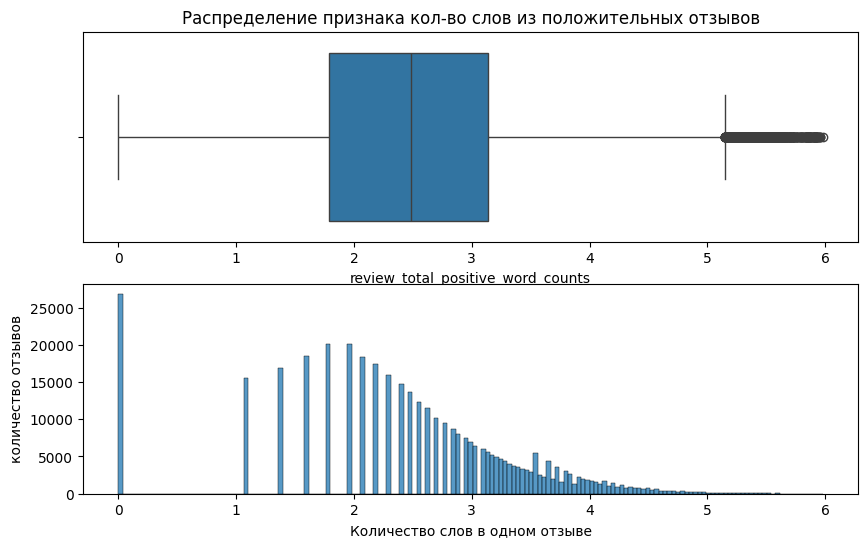

In [158]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='review_total_positive_word_counts', ax=axes[0]);
boxplot.set_title('Распределение признака кол-во слов из положительных отзывов');

histplot = sns.histplot(data=hotels, x='review_total_positive_word_counts', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(xlabel='Количество слов в одном отзыве', ylabel='количество отзывов')

plt.show()

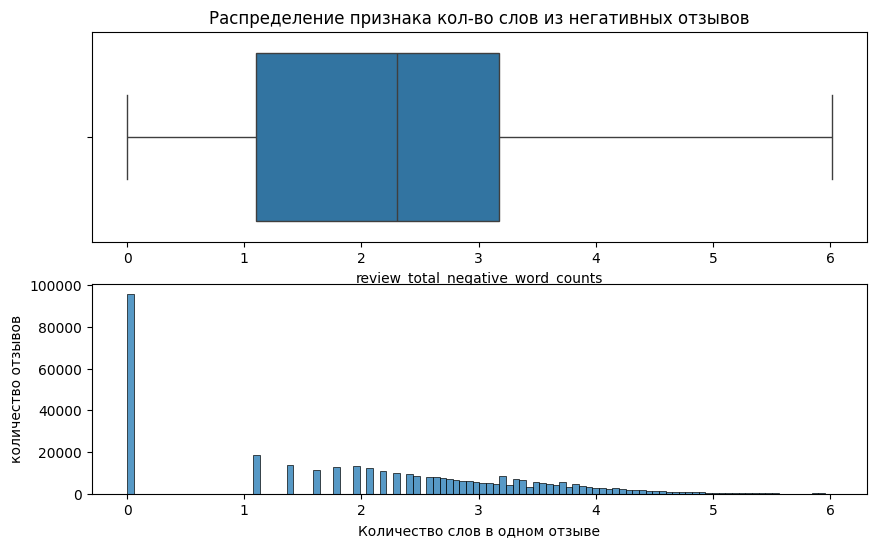

In [159]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='review_total_negative_word_counts', ax=axes[0]);
boxplot.set_title('Распределение признака кол-во слов из негативных отзывов');

histplot = sns.histplot(data=hotels, x='review_total_negative_word_counts', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(xlabel='Количество слов в одном отзыве', ylabel='количество отзывов')

plt.show()

#### После визуальной оценки признаков 'review_total_positive_word_counts' и 'review_total_negative_word_counts'применим к ним несколько действий позволяющие облегчить модели делать верные выводы

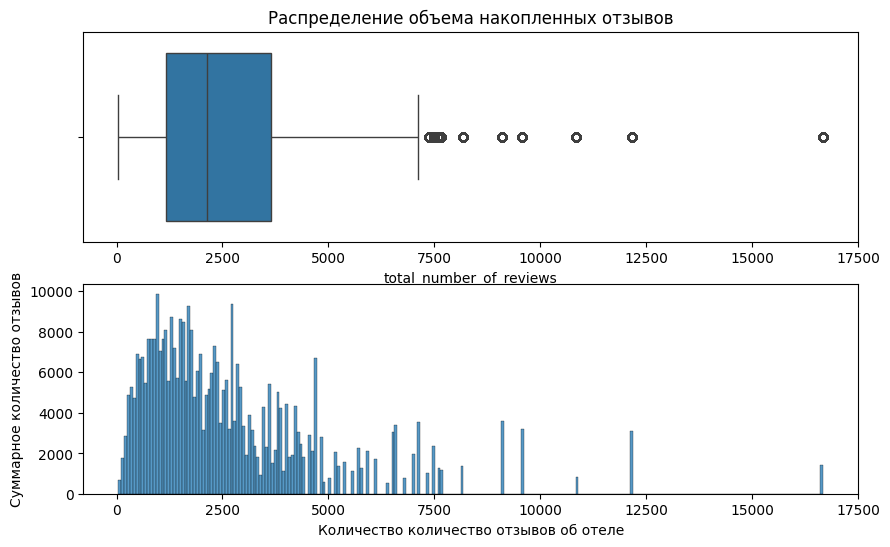

In [160]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='total_number_of_reviews', ax=axes[0]);
boxplot.set_title('Распределение объема накопленных отзывов');

histplot = sns.histplot(data=hotels, x='total_number_of_reviews', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(xlabel='Количество количество отзывов об отеле', ylabel='Суммарное количество отзывов')

plt.show()

In [161]:
mask = hotels['total_number_of_reviews'] > 11000
over_limit = hotels[mask].shape[0]
print(over_limit)
limit = 11000
hotels['total_number_of_reviews'] = (
    hotels['total_number_of_reviews'].apply(lambda x: x if x <= limit else limit))

4506


In [162]:
hotels['total_number_of_reviews_reviewer_has_given'] = np.log1p(hotels['total_number_of_reviews_reviewer_has_given'])

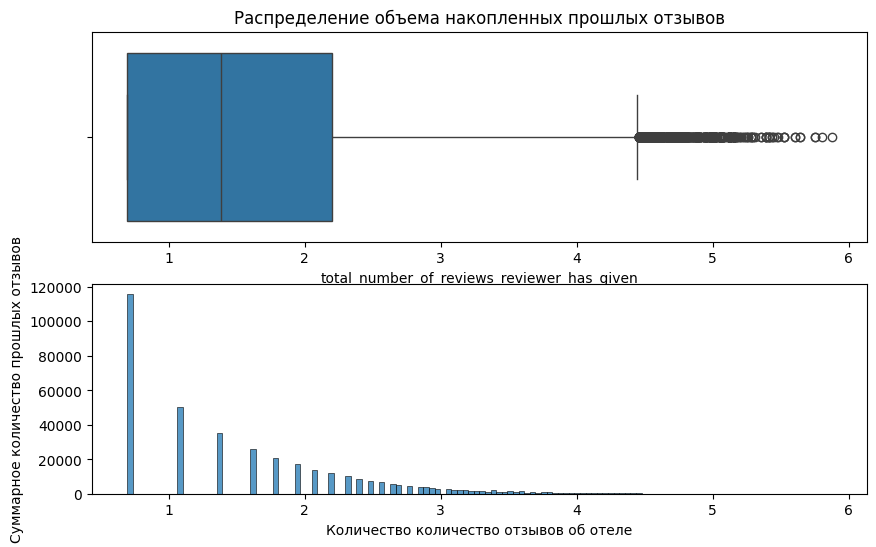

In [163]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='total_number_of_reviews_reviewer_has_given', ax=axes[0]);
boxplot.set_title('Распределение объема накопленных прошлых отзывов');

histplot = sns.histplot(data=hotels, x='total_number_of_reviews_reviewer_has_given', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(xlabel='Количество количество отзывов об отеле', ylabel='Суммарное количество прошлых отзывов')

plt.show()

In [164]:
# mask = hotels['total_number_of_reviews_reviewer_has_given'] > 4.5
# over_limit = hotels[mask].shape[0]
# print(over_limit)
# limit = 4.5
# hotels['total_number_of_reviews_reviewer_has_given'] = (
#     hotels['total_number_of_reviews_reviewer_has_given'].apply(lambda x: x if x <= limit else limit))

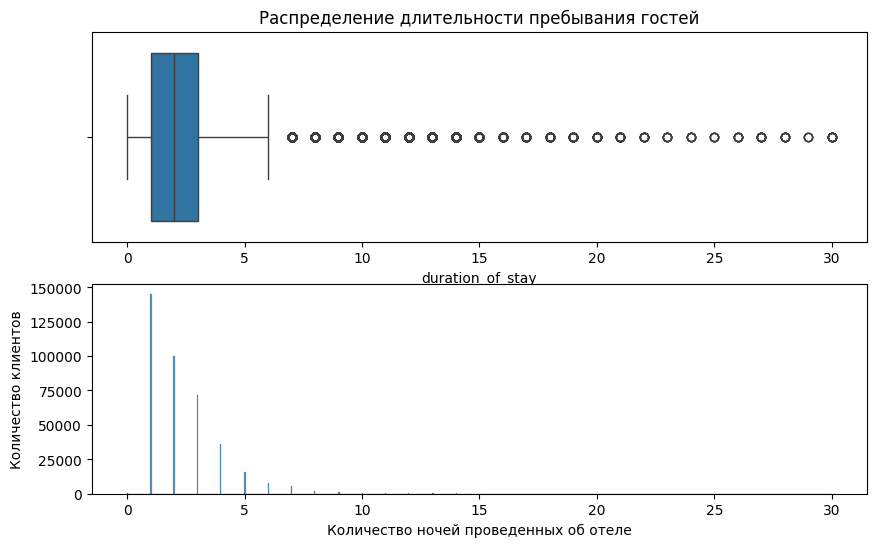

In [165]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))

boxplot = sns.boxplot(data=hotels, x='duration_of_stay', ax=axes[0]);
boxplot.set_title('Распределение длительности пребывания гостей');

histplot = sns.histplot(data=hotels, x='duration_of_stay', ax=axes[1]);
# histplot.set_title('Cleaned Full Square Distribution');
axes[1].set(xlabel='Количество ночей проведенных об отеле', ylabel='Количество клиентов')

plt.show()

In [166]:
mask = hotels['duration_of_stay'] > 14
over_limit = hotels[mask].shape[0]
print(over_limit)

hotels['duration_of_stay'] = hotels['duration_of_stay'].clip(upper=14)

294


##### Проведем корреляционный анализ

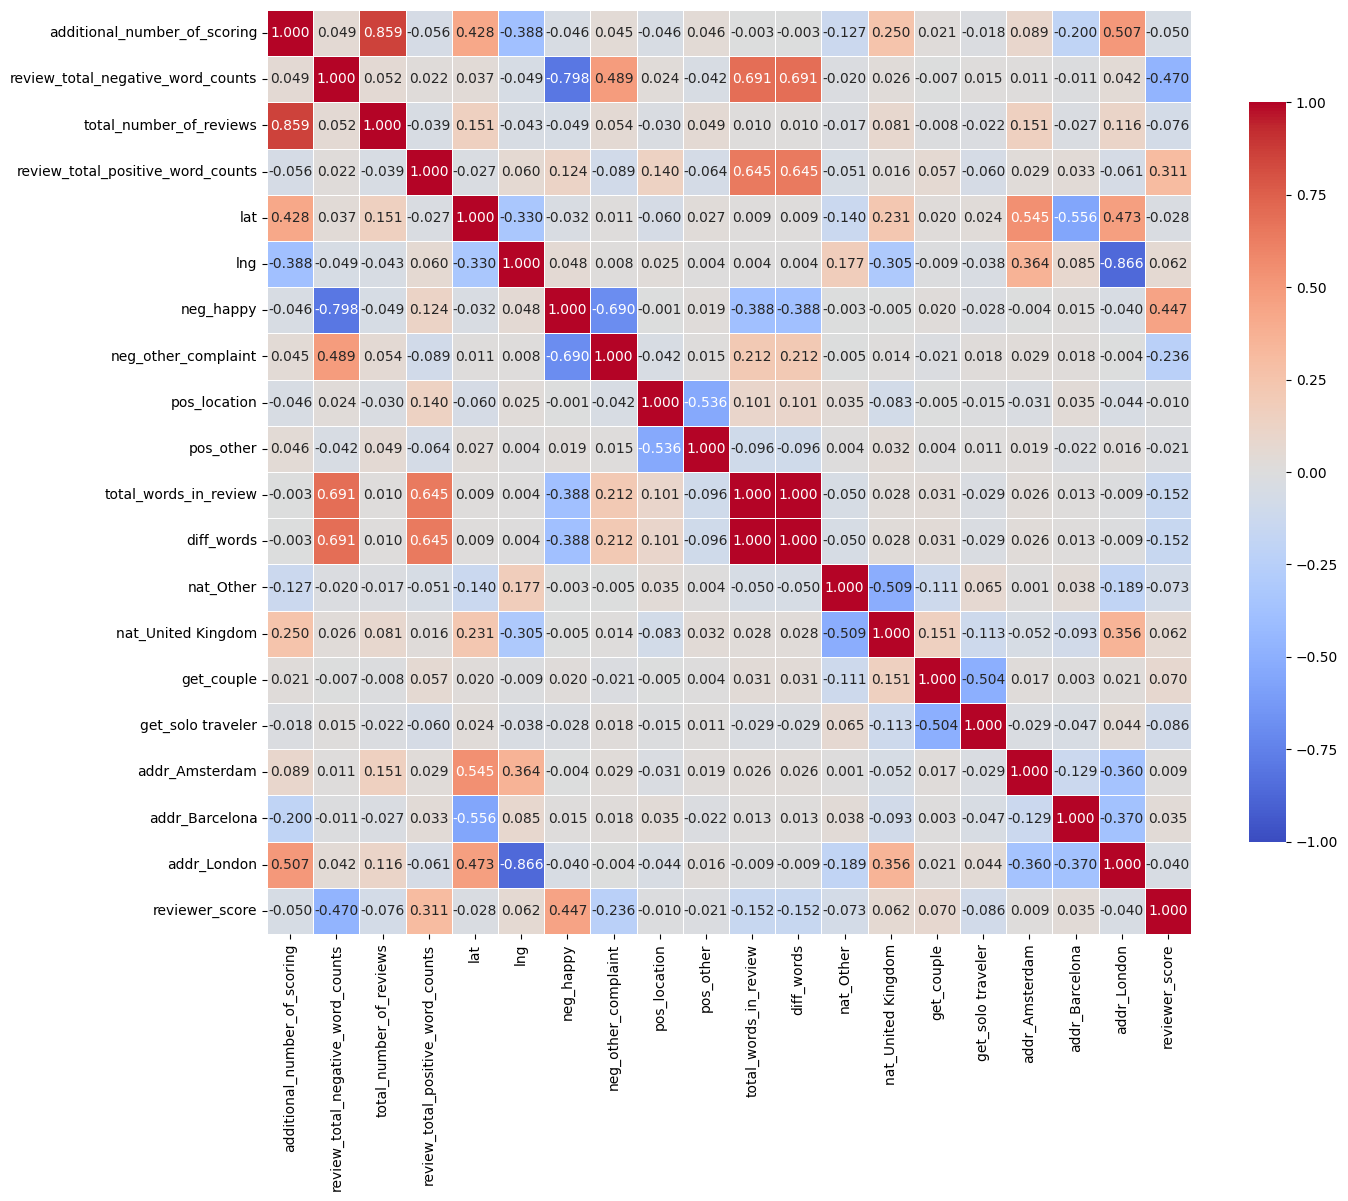

In [167]:
# 1. Считаем корреляцию
corr = hotels.corr(numeric_only=True, method='spearman') 

# 2. Создаем маску
strong_filter = (abs(corr) > 0.5) & (abs(corr) < 1.0)

# 3. Формируем список (один раз!)
cols_to_keep = corr.columns[strong_filter.any()].tolist()

# 4. Добавляем таргет, если его там нет
target_col = 'reviewer_score'
if target_col not in cols_to_keep:
    cols_to_keep.append(target_col)

# 5. Обрезаем матрицу (используем уже готовый cols_to_keep)
filtered_corr = corr.loc[cols_to_keep, cols_to_keep]

# 4. Строим карту (теперь она будет намного крупнее, так как колонок меньше)
plt.figure(figsize=(15, 12))
sns.heatmap(
    filtered_corr, 
    annot=True, 
    cmap='coolwarm',
    linewidths=0.5, 
    fmt=".3f", 
    vmin=-1, vmax=1,
    square=True, # Делает ячейки идеально квадратными
    cbar_kws={"shrink": .8}
)
plt.show()

#### Проверим правильтность коэффициентов корреляции бинарных признаков

In [168]:
from sklearn.metrics import matthews_corrcoef

# Пример: связь мобильных устройств и бизнес-поездок
mcc = matthews_corrcoef(hotels['is_mobile'], hotels['get_solo traveler'])
print(f"Коэффициент Мэтьюса для мобильных и одиноких: {mcc:.3f}")

Коэффициент Мэтьюса для мобильных и одиноких: -0.107


In [169]:
mcc = matthews_corrcoef(hotels['addr_Barcelona'], hotels['get_solo traveler'])
print(f"Коэффициент Мэтьюса для из Барселоны и одиноких: {mcc:.3f}")

Коэффициент Мэтьюса для из Барселоны и одиноких: -0.047


##### **Вывод:** результаты одинаковые, значит коэфф корреляции на тепловой карте отображены верно

##### Коэффициент корреляции превышает допустимые границы у двух пар признаков это: 
* пара: 'additional_number_of_scoring' и 'total_number_of_reviews'
* пара: 'addr_London' и 'lng' 
* пара 
Из этих двух пар я оставлю более важные и информативные признаки. Два признаки которые я считаю менее важными я удалю

In [170]:
# Удаление менее важных признаков у которых высокий коэф. корреляции
hotels = hotels.drop(['additional_number_of_scoring', 'addr_London', 'total_words_in_review'], axis=1)

#### Переходим к подготовке модели к обучению

In [171]:
# Список признаков который будем удалять из X
list_drop = [
    'get_Unknown', 'addr_Vienna', 'addr_Amsterdam', 'addr_Barcelona', 
    'nat_Belgium', 'nat_Canada', 'nat_Israel', 'nat_Italy'
    ]

In [176]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х — данные с информацией об отелях, у — целевая переменная (рейтинги отелей)
X = hotels.drop('reviewer_score', axis=1) 
y = hotels['reviewer_score']

X = X.drop(list_drop, axis=1)

# Загружаем специальный инструмент для разбивки: 
from sklearn.model_selection import train_test_split

# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" — для тестирования.  
# Для тестирования мы будем использовать 25 % от исходного датасета

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [173]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
Index: 386496 entries, 0 to 386802
Data columns (total 56 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   average_score                               386496 non-null  float64
 1   review_total_negative_word_counts           386496 non-null  float64
 2   total_number_of_reviews                     386496 non-null  int64  
 3   review_total_positive_word_counts           386496 non-null  float64
 4   total_number_of_reviews_reviewer_has_given  386496 non-null  float64
 5   reviewer_score                              386496 non-null  float64
 6   days_since_review                           386496 non-null  int64  
 7   lat                                         386496 non-null  float64
 8   lng                                         386496 non-null  float64
 9   neg_breakfast                               386496 non-null  int64  
 10  n

In [ ]:
# Непрерывные признаки
num_cols = [
    'average_score', 'review_total_negative_word_counts', 'lat', 'lng',
    'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given',
    'dist_center', 'days_since_review', 'diff_words', 'total_number_of_reviews'
    ]
# Категориальные признаки: 
cat_cols = [
    'neg_breakfast', 'neg_happy', 'neg_other_complaint', 'neg_small_room', 
    'dis_positive','is_positive', 'pos_displeased', 'pos_location', 'pos_other', 
    'pos_perfect', 'pos_staff', 'trip_purpose', 'is_mobile', 'duration_of_stay',
    'month_date', 'day_date', 'addr_Milan', 'addr_Paris', 'nat_Australia', 
    'nat_Netherlands', 'nat_France', 'nat_Germany', 'nat_Ireland', 'nat_Switzerland', 
    'nat_Other', 'nat_Saudi Arabia', 'nat_Turkey', 'nat_United Arab Emirates', 
    'nat_United Kingdom', 'nat_United States of America', 'get_couple',
    'get_family with older children', 'get_family with young children',
    'get_group', 'get_solo traveler', 'amount_word', 'lux_weight' 
    ]

'addr_Amsterdam', 'addr_Barcelona', 'addr_Vienna', 'nat_Belgium', 'nat_Canada', 'nat_Israel', 'nat_Italy', 'get_Unknown',

amount_word                         31.502450
nat_Ireland                         56.925737
day_date                            64.240050
get_family with older children      85.298643
addr_Paris                          87.561657
addr_Milan                          95.046373
get_group                           97.835647
nat_France                         144.360755
get_family with young children     186.371642
nat_Australia                      229.528422
nat_Germany                        253.252129
nat_Turkey                         276.958997
duration_of_stay                   432.264500
trip_purpose                       484.086691
is_mobile                          624.603036
lux_weight                         647.993993
nat_Saudi Arabia                   665.209885
month_date                         731.116137
nat_United Arab Emirates           743.272562
nat_United Kingdom                 943.462603
get_couple                         998.844069
nat_Other                         

<Axes: >

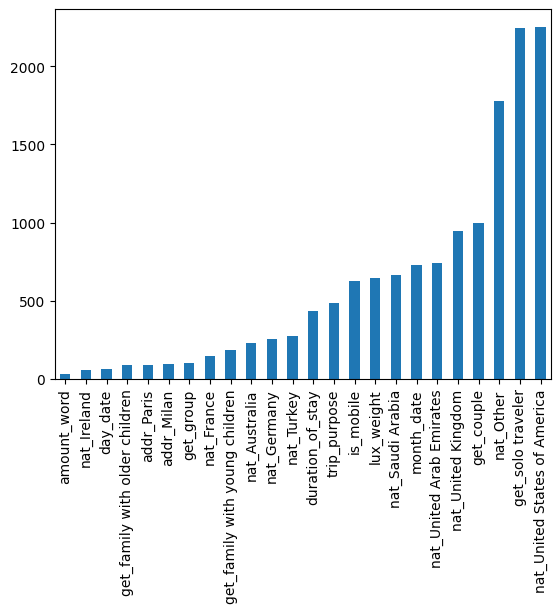

In [177]:
y_0 = y.astype('int')

from sklearn.feature_selection import chi2

imp_cat = pd.Series(chi2(X[cat_cols], y_0)[0], index = cat_cols)
imp_cat.sort_values(inplace = True)
display(imp_cat)
imp_cat.plot(kind='bar')

days_since_review                                26.722059
lat                                              75.584353
lng                                              92.426175
dist_center                                     186.526036
total_number_of_reviews                         292.574747
total_number_of_reviews_reviewer_has_given      401.009049
review_total_positive_word_counts              6690.361842
average_score                                  7588.683414
review_total_negative_word_counts             13920.291102
dtype: float64

<Axes: >

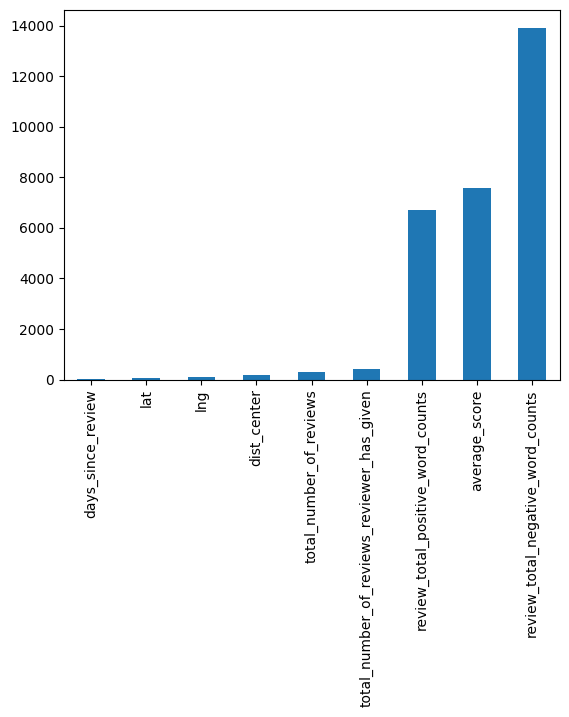

In [178]:
from sklearn.feature_selection import f_classif 

imp_num = pd.Series(f_classif(X[num_cols], y_0)[0], index = num_cols)
imp_num.sort_values(inplace=True)
display(imp_num)
imp_num.plot(kind = 'bar')

#### По результатам тестов chi2 и f_classif можно выделить малозначимые признаки, которые следует удаоить. Удалять я буду следующие признаки: 
* 'get_Unknown';

Эти признаки мы будем удалять выше этого кода в ячейке 68, а затем перезапустим ячейку 68, а затем запустим сразу ячейки: 76 и 77. 

**ВНИМАНИЕ!!!** Перед перезапуском кода "Выполнить все" необходимо закоментровать строки кода: 
1. в ячейке 68 код  X = X.drop(['get_Unknown', 'nat_Ireland', 'days_since_review', 'duration_of_stay', 'lat'], axis=1); 
2. ячейку 76;
3. ячейку 77. 

После выполнения всех сторк кода, необходимо расскоментировать вышеуказанные строки и перезапустить отдельно ячейку: 68, 76 и 77

In [ ]:
# # Импортируем необходимые библиотеки:  
# from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
# from sklearn import metrics # инструменты для оценки точности модели  
      
# # Создаём модель  
# regr = RandomForestRegressor(n_estimators=50)  
      
# # Обучаем модель на тестовом наборе данных  
# regr.fit(X_train, y_train)  
      
# # Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# # Предсказанные значения записываем в переменную y_pred  
# y_pred = regr.predict(X_test)

In [ ]:
# # Смотрим, какие признаки модель считает самыми важными
# plt.figure(figsize=(10,5))
# importances = pd.Series(regr.feature_importances_, index=X.columns)
# importances.sort_values().plot(kind='bar')
# display(importances.sort_values())

In [ ]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
# print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13214768716439718
